# <p style="font-family: Cambria; text-align: center; font-size: 44px;">III. PRESCRIPTIVE ANALYSIS </p>



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import fisher_exact, chi2_contingency, spearmanr
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("Team2_PythonPioneers_Cardiac_Cleaned_Data.csv")
print(df.shape)

(2008, 210)


In [2]:
# Show very small p-values as "<0.001"
def p_text(p):
    if p < 0.001:
        return "<0.001"
    return round(float(p), 3)

# Chi-square test: is the outcome rate different between groups?
def chi_square(group_col, outcome_col, data):
    table = pd.crosstab(data[group_col], data[outcome_col])
    chi2, p, dof, expected = stats.chi2_contingency(table)
    return p_text(p)

# Fisher test for two groups: returns odds ratio and p-value
def fisher(flag_col, outcome_col, data):
    table = pd.crosstab(data[flag_col], data[outcome_col])
    odds_ratio, p = stats.fisher_exact(table.values)
    return round(float(odds_ratio), 2), p_text(p)

# Mann-Whitney test: are the values different in patients who died vs survived?
def mann_whitney(value_col, outcome_col, data):
    died = data.loc[data[outcome_col] == 1, value_col].dropna()
    survived = data.loc[data[outcome_col] == 0, value_col].dropna()
    u, p = stats.mannwhitneyu(died, survived)
    return round(float(died.median()), 2), round(float(survived.median()), 2), p_text(p)

# 1 = patient died in hospital
df["in_hospital_death"] = (df["outcome_during_hospitalization"] == "Dead").astype(int)

<p style="font-family: Cambria; font-size: 16px; color:red;"><b>Q1. Does an elevated BNP level at admission identify heart-failure patients who have a higher risk of readmission or death at 28 days, 3 months and 6 months, and what BNP range is associated with the greatest observed risk?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>brain_natriuretic_peptide, re_admission_within_28_days / 3_months / 6_months, death_within_28_days / 3_months / 6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>BNP (brain natriuretic peptide) is a hormone released by the heart walls when they are stretched by too much blood and pressure. The more fluid builds up and the harder the heart has to work, the higher BNP goes, so it is the main blood test used to measure how bad heart failure is. A heart under heavy strain is more likely to fail again after discharge (readmission) and has less reserve to survive (death). In our data about 93% of patients are above the normal limit of 100, so the normal limit cannot separate high-risk patients. We split BNP into four equal groups, plus the 100 patients stuck at the machine limit of 5000, to find the BNP range where risk really rises at 28 days, 3 months and 6 months.</b></i></p>

In [3]:
q1 = df.dropna(subset=["brain_natriuretic_peptide"]).copy()

# BNP groups: 4 equal groups for patients below 5000, and a separate group for the machine limit (5000)
q1["BNP group"] = "Capped 5000"
below = q1["brain_natriuretic_peptide"] < 5000
q1.loc[below, "BNP group"] = pd.qcut(q1.loc[below, "brain_natriuretic_peptide"], 4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4"]).astype(str)
print(q1.loc[below].groupby("BNP group")["brain_natriuretic_peptide"].agg(["min", "max"]).round(0))

# Readmission and death rate (%) in each BNP group
outcomes = ["re_admission_within_28_days", "re_admission_within_3_months", "re_admission_within_6_months",
            "death_within_28_days", "death_within_3_months", "death_within_6_months"]
bnp_table = (q1.groupby("BNP group")[outcomes].mean() * 100).round(1)
bnp_table["patients"] = q1["BNP group"].value_counts()
bnp_table = bnp_table.loc[["Q1 (lowest)", "Q2", "Q3", "Q4", "Capped 5000"]]
print(bnp_table)

# Chi-square test for each outcome
for col in outcomes:
    print(col, "p-value:", chi_square("BNP group", col, q1))

# Compare BNP 708 and above with below 708 (6-month death)
q1["bnp_708_plus"] = (q1["brain_natriuretic_peptide"] >= 708).astype(int)
print("BNP >= 708 vs below, 6-month death: odds ratio and p-value", fisher("bnp_708_plus", "death_within_6_months", q1))

                min     max
BNP group                  
Q1 (lowest)     3.0   285.0
Q2            287.0   708.0
Q3            709.0  1524.0
Q4           1525.0  4983.0
             re_admission_within_28_days  re_admission_within_3_months  \
BNP group                                                                
Q1 (lowest)                          7.5                          22.2   
Q2                                   3.8                          19.9   
Q3                                   8.5                          25.6   
Q4                                   7.3                          30.1   
Capped 5000                          9.0                          27.0   

             re_admission_within_6_months  death_within_28_days  \
BNP group                                                         
Q1 (lowest)                          37.3                   0.6   
Q2                                   34.8                   1.1   
Q3                                   38.9    

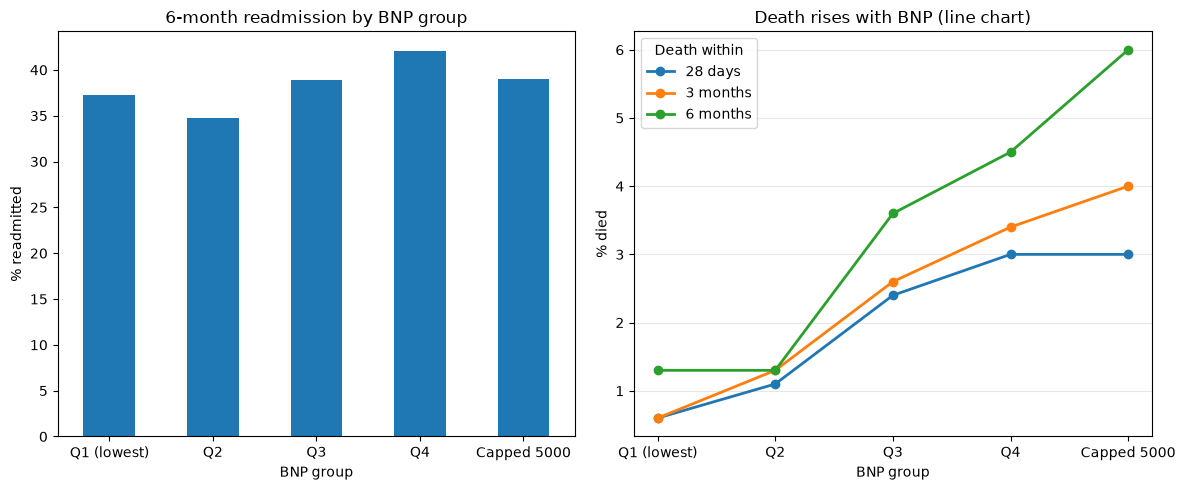

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bnp_table[["re_admission_within_6_months"]].plot(kind="bar", ax=axes[0], legend=False, rot=0)
axes[0].set_title("6-month readmission by BNP group")
axes[0].set_ylabel("% readmitted")
# Line chart: death rises with BNP at every time point
for col, name in [("death_within_28_days", "28 days"), ("death_within_3_months", "3 months"), ("death_within_6_months", "6 months")]:
    axes[1].plot(bnp_table.index, bnp_table[col], marker="o", linewidth=2, label=name)
axes[1].set_title("Death rises with BNP (line chart)")
axes[1].set_xlabel("BNP group")
axes[1].set_ylabel("% died")
axes[1].legend(title="Death within")
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Higher BNP clearly goes with more deaths at every time point: 6-month death is 1.3% in the two lowest BNP groups, 3.6% at BNP 708–1,524, 4.5% at 1,524–4,983 and 6.0% at the machine limit of 5000. Patients with BNP of 708 or more have about 3.4 times the odds of dying within 6 months compared with patients below 708 (p < 0.001). Readmission is only weakly linked: it rises a little at 3 months (22% to 30%) but is not significant at 6 months (35% to 42%, p = 0.24). So BNP is mainly a death-risk marker in this data.<br><b>What this means:</b> patients with BNP of 708 pg/mL or more should get a death-risk review and an early clinic visit, and patients at 5000 are the highest-risk group. BNP should not be used on its own to plan readmission prevention.</b></i></p>

<p style="font-family: Cambria; font-size: 16px; color:red;"><b>Q2. Do elevated cardiac injury biomarkers, including troponin, CK-MB and myoglobin, at admission identify patients at higher risk of in-hospital and 28-day mortality?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>high_sensitivity_troponin (>14), creatine_kinase_isoenzyme (CK-MB >32), myoglobin (>72), outcome_during_hospitalization, death_within_28_days</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Troponin, CK-MB and myoglobin are proteins inside heart muscle cells. When heart muscle is short of blood or damaged, the cells break and these proteins leak into the blood. Damaged muscle pumps less, can trigger dangerous heart rhythms, and the damage may still be going on. Troponin is the most sensitive, CK-MB rises with bigger damage and myoglobin rises first, so more high markers means bigger or ongoing damage. We test whether this group of markers identifies patients at risk of dying soon, in hospital or within 28 days. Normal limits are taken from the data dictionary.</b></i></p>

In [5]:
q2 = df.dropna(subset=["high_sensitivity_troponin"]).copy()

# 1 = marker above the normal limit from the data dictionary (a missing test counts as not high)
q2["troponin_high"] = (q2["high_sensitivity_troponin"] > 14).astype(int)
q2["ckmb_high"] = (q2["creatine_kinase_isoenzyme"] > 32).astype(int)
q2["myoglobin_high"] = (q2["myoglobin"] > 72).astype(int)
q2["markers_high"] = q2["troponin_high"] + q2["ckmb_high"] + q2["myoglobin_high"]
q2["Injury group"] = q2["markers_high"].replace({0: "0 high", 1: "1 high", 2: "2-3 high", 3: "2-3 high"})

print("% of patients with high troponin:", round(q2["troponin_high"].mean() * 100, 1))

# Death rate (%) in each injury group
injury_table = (q2.groupby("Injury group")[["in_hospital_death", "death_within_28_days"]].mean() * 100).round(1)
injury_table["patients"] = q2["Injury group"].value_counts()
print(injury_table)

# Statistical tests
print("Injury group vs in-hospital death, p-value:", chi_square("Injury group", "in_hospital_death", q2))
print("Injury group vs 28-day death, p-value:", chi_square("Injury group", "death_within_28_days", q2))
print("CK-MB high vs 28-day death: odds ratio and p-value", fisher("ckmb_high", "death_within_28_days", q2))
q2["two_plus"] = (q2["markers_high"] >= 2).astype(int)
print("2-3 markers high vs 28-day death: odds ratio and p-value", fisher("two_plus", "death_within_28_days", q2))
print("Troponin median (died, survived) and p-value:", mann_whitney("high_sensitivity_troponin", "death_within_28_days", q2))

% of patients with high troponin: 83.5
              in_hospital_death  death_within_28_days  patients
Injury group                                                   
0 high                      0.0                   0.0       284
1 high                      0.6                   1.3      1342
2-3 high                    0.3                   5.9       303
Injury group vs in-hospital death, p-value: 0.379
Injury group vs 28-day death, p-value: <0.001
CK-MB high vs 28-day death: odds ratio and p-value (5.45, '<0.001')
2-3 markers high vs 28-day death: odds ratio and p-value (5.98, '<0.001')
Troponin median (died, survived) and p-value: (134.0, 53.0, '<0.001')


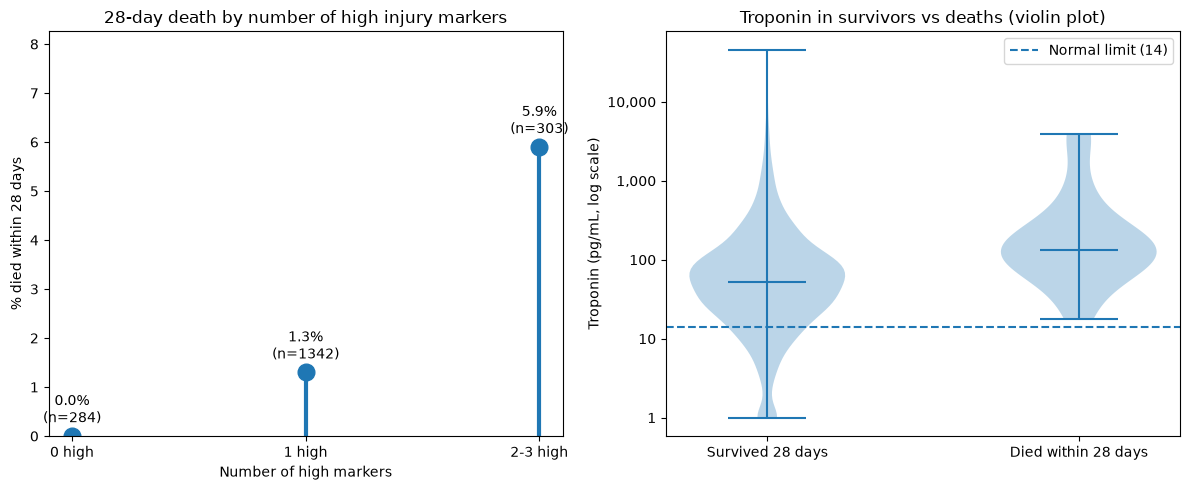

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Lollipop chart: 28-day death by number of high injury markers
order = ["0 high", "1 high", "2-3 high"]
values = injury_table.loc[order, "death_within_28_days"]
axes[0].vlines(order, 0, values, linewidth=3)
axes[0].plot(order, values, "o", markersize=12)
for x, v, n in zip(order, values, injury_table.loc[order, "patients"]):
    axes[0].annotate(f"{v:.1f}%\n(n={n})", (x, v), textcoords="offset points", xytext=(0, 10), ha="center")
axes[0].set_ylim(0, values.max() * 1.4)
axes[0].set_title("28-day death by number of high injury markers")
axes[0].set_xlabel("Number of high markers")
axes[0].set_ylabel("% died within 28 days")
# Violin plot: troponin (log scale) in survivors vs deaths
survived = np.log10(q2.loc[q2["death_within_28_days"] == 0, "high_sensitivity_troponin"].clip(lower=1))
died = np.log10(q2.loc[q2["death_within_28_days"] == 1, "high_sensitivity_troponin"].clip(lower=1))
axes[1].violinplot([survived, died], showmedians=True)
axes[1].axhline(np.log10(14), linestyle="--", label="Normal limit (14)")
axes[1].set_xticks([1, 2], ["Survived 28 days", "Died within 28 days"])
axes[1].set_yticks([0, 1, 2, 3, 4], ["1", "10", "100", "1,000", "10,000"])
axes[1].set_title("Troponin in survivors vs deaths (violin plot)")
axes[1].set_ylabel("Troponin (pg/mL, log scale)")
axes[1].legend()
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Troponin is high in 83.5% of patients, so almost everyone has some heart muscle damage. Even so, damage is clearly linked to early death: 28-day death is 0% with no high markers, 1.3% with one and 5.9% with two or three. Patients who died within 28 days had a median troponin of 134 vs 53 in survivors. CK-MB above 32 raises the odds of 28-day death about 5.5 times, and 2 to 3 high markers 6 times. In-hospital death does not differ, but only 11 patients died in hospital, and myoglobin is missing for about 80% of patients.<br><b>What this means:</b> patients with two or more high injury markers (303 patients), especially a high CK-MB, should get heart monitoring, a repeat troponin and a check for blocked arteries. A high troponin alone is too common to be a useful warning sign.</b></i></p>

<p style="font-family: Cambria; font-size: 16px; color:red;"><b>Q3. Do elevated inflammatory biomarkers (hs-CRP, WBC and NLR), particularly when combined with low albumin, identify patients at higher risk of death?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>hs_crp (>5), white_blood_cell (>10), NLR = neutrophil_count / lymphocyte_count (>6), albumin (<35), death_within_28_days, death_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>hs-CRP, white blood cells (WBC) and the neutrophil-to-lymphocyte ratio (NLR) show how much inflammation is in the body. In heart failure, inflammation damages the heart muscle and blood vessels, and it is often a sign of infection, which is a common trigger for heart failure getting worse. Albumin is the main protein made by the liver; it falls when the patient is poorly nourished, very inflamed, or has a congested liver, and low albumin lets fluid leak out of the blood vessels, which adds to swelling. A patient who is both inflamed and has low albumin has less strength to recover, so this group of markers should point to patients with a higher risk of death.</b></i></p>

In [7]:
q3 = df.dropna(subset=["albumin"]).copy()
q3["nlr"] = q3["neutrophil_count"] / q3["lymphocyte_count"]

# Inflamed = at least one marker high; low albumin = below 35
q3["inflamed"] = ((q3["hs_crp"] > 5) | (q3["white_blood_cell"] > 10) | (q3["nlr"] > 6)).astype(int)
q3["low_albumin"] = (q3["albumin"] < 35).astype(int)

def group_name(row):
    if row["inflamed"] == 1 and row["low_albumin"] == 1: return "Both"
    if row["inflamed"] == 1: return "Inflamed only"
    if row["low_albumin"] == 1: return "Low albumin only"
    return "Neither"
q3["Group"] = q3.apply(group_name, axis=1)

# Death rate (%) in each group
infl_table = (q3.groupby("Group")[["death_within_28_days", "death_within_6_months", "re_admission_within_6_months"]].mean() * 100).round(1)
infl_table["patients"] = q3["Group"].value_counts()
infl_table = infl_table.loc[["Neither", "Inflamed only", "Low albumin only", "Both"]]
print(infl_table)

# Each marker: median in patients who died within 28 days vs survived
for col in ["hs_crp", "white_blood_cell", "nlr", "albumin"]:
    print(col, "median (died, survived) and p-value:", mann_whitney(col, "death_within_28_days", q3))

print("Group vs 28-day death, p-value:", chi_square("Group", "death_within_28_days", q3))
both_neither = q3[q3["Group"].isin(["Both", "Neither"])].copy()
both_neither["is_both"] = (both_neither["Group"] == "Both").astype(int)
print("Both vs Neither, 6-month death: odds ratio and p-value", fisher("is_both", "death_within_6_months", both_neither))

                  death_within_28_days  death_within_6_months  \
Group                                                           
Neither                            0.5                    1.4   
Inflamed only                      1.6                    2.6   
Low albumin only                   0.5                    1.8   
Both                               3.9                    4.9   

                  re_admission_within_6_months  patients  
Group                                                     
Neither                                   43.6       573  
Inflamed only                             36.5       685  
Low albumin only                          39.2       217  
Both                                      32.9       431  
hs_crp median (died, survived) and p-value: (43.9, 9.35, 0.004)
white_blood_cell median (died, survived) and p-value: (8.76, 6.47, 0.003)
nlr median (died, survived) and p-value: (8.52, 5.16, '<0.001')
albumin median (died, survived) and p-value: (34.5, 3

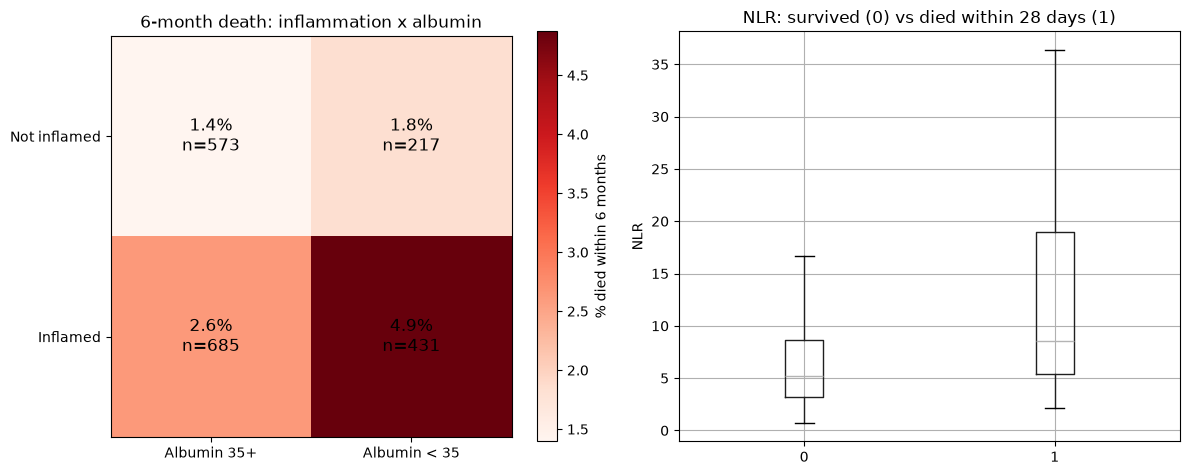

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# 2x2 heatmap: inflamed (yes/no) x low albumin (yes/no), colour = 6-month death %
rate = q3.pivot_table(index="inflamed", columns="low_albumin", values="death_within_6_months", aggfunc="mean") * 100
count = pd.crosstab(q3["inflamed"], q3["low_albumin"])
im = axes[0].imshow(rate.values, cmap="Reds")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f"{rate.iloc[i, j]:.1f}%\nn={count.iloc[i, j]}", ha="center", va="center", fontsize=12)
axes[0].set_xticks([0, 1], ["Albumin 35+", "Albumin < 35"])
axes[0].set_yticks([0, 1], ["Not inflamed", "Inflamed"])
axes[0].set_title("6-month death: inflammation x albumin")
plt.colorbar(im, ax=axes[0], label="% died within 6 months")
q3.boxplot(column="nlr", by="death_within_28_days", ax=axes[1], showfliers=False)
axes[1].set_title("NLR: survived (0) vs died within 28 days (1)")
axes[1].set_xlabel("")
axes[1].set_ylabel("NLR")
plt.suptitle("")
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>All four markers are clearly different in patients who died within 28 days: median hs-CRP 43.9 vs 9.4, WBC 8.8 vs 6.5, NLR 8.5 vs 5.2 and albumin 34.5 vs 36.8 (all significant). Combining them works best: patients who are both inflamed and low in albumin have 3.9% 28-day death and 4.9% 6-month death, compared with 0.5% and 1.4% for patients with neither (odds ratio 3.6). Inflammation alone or low albumin alone adds much less risk. Readmission does not follow the same pattern (it is highest in the 'neither' group), so these markers mainly warn about death.<br><b>What this means:</b> patients with high inflammation markers and albumin below 35 (431 patients) should be checked for infection, get a nutrition review and a death-risk review before discharge. hs-CRP is missing for about half of patients, so WBC and NLR, which are available for almost everyone, are the practical markers to use.</b></i></p>

<p style="font-family: Cambria; font-size: 16px; color:red;"><b>Q4. Are lower hemoglobin and higher RDW associated with more severe NYHA heart-failure class and higher rates of readmission and death?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>hemoglobin (anemia: <130 men, <120 women), coefficient_of_variation_of_red_blood_cell_distribution_width (RDW >15), nyha_cardiac_function_classification, re_admission_within_6_months, death_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Hemoglobin carries oxygen in the blood. When it is low (anemia), the heart has to pump faster and harder to deliver enough oxygen, which puts extra strain on an already weak heart and makes the patient more breathless. RDW measures how much red blood cells vary in size; a high RDW often means iron shortage or poor red cell production and is a known warning sign in heart failure. Together these markers should link to worse symptoms (higher NYHA class) and more readmissions and deaths.</b></i></p>

In [9]:
q4 = df.dropna(subset=["hemoglobin"]).copy()
rdw = "coefficient_of_variation_of_red_blood_cell_distribution_width"

# Anemia: hemoglobin below 130 for men and below 120 for women; high RDW: above 15
q4["anemia"] = np.where(q4["gender"] == "Male", q4["hemoglobin"] < 130, q4["hemoglobin"] < 120).astype(int)
q4["rdw_high"] = (q4[rdw] > 15).astype(int)
print("% of patients with anemia:", round(q4["anemia"].mean() * 100, 1))

# NYHA class mix (%) for anemic and non-anemic patients
print((pd.crosstab(q4["anemia"], q4["nyha_cardiac_function_classification"], normalize="index") * 100).round(1))

# Outcomes (%) for anemia and high RDW
print((q4.groupby("anemia")[["re_admission_within_6_months", "death_within_6_months"]].mean() * 100).round(1))
print((q4.groupby("rdw_high")[["re_admission_within_6_months", "death_within_6_months"]].mean() * 100).round(1))

# Statistical tests
print("Anemia vs NYHA class, p-value:", chi_square("anemia", "nyha_cardiac_function_classification", q4))
rho, p = stats.spearmanr(q4["hemoglobin"], q4["nyha_cardiac_function_classification"])
print("Hemoglobin vs NYHA class: rho =", round(rho, 3), "p =", p_text(p))
print("Anemia vs 6-month readmission: odds ratio and p-value", fisher("anemia", "re_admission_within_6_months", q4))
print("Anemia vs 6-month death: odds ratio and p-value", fisher("anemia", "death_within_6_months", q4))
print("High RDW vs 6-month death: odds ratio and p-value", fisher("rdw_high", "death_within_6_months", q4))

% of patients with anemia: 60.9
nyha_cardiac_function_classification     2     3     4
anemia                                                
0                                     17.3  54.2  28.5
1                                     17.3  50.5  32.3
        re_admission_within_6_months  death_within_6_months
anemia                                                     
0                               35.4                    2.5
1                               40.7                    3.1
          re_admission_within_6_months  death_within_6_months
rdw_high                                                     
0                                 38.2                    2.5
1                                 39.5                    3.6
Anemia vs NYHA class, p-value: 0.179
Hemoglobin vs NYHA class: rho = -0.027 p = 0.226
Anemia vs 6-month readmission: odds ratio and p-value (1.26, 0.018)
Anemia vs 6-month death: odds ratio and p-value (1.26, 0.488)
High RDW vs 6-month death: odds ratio and p-

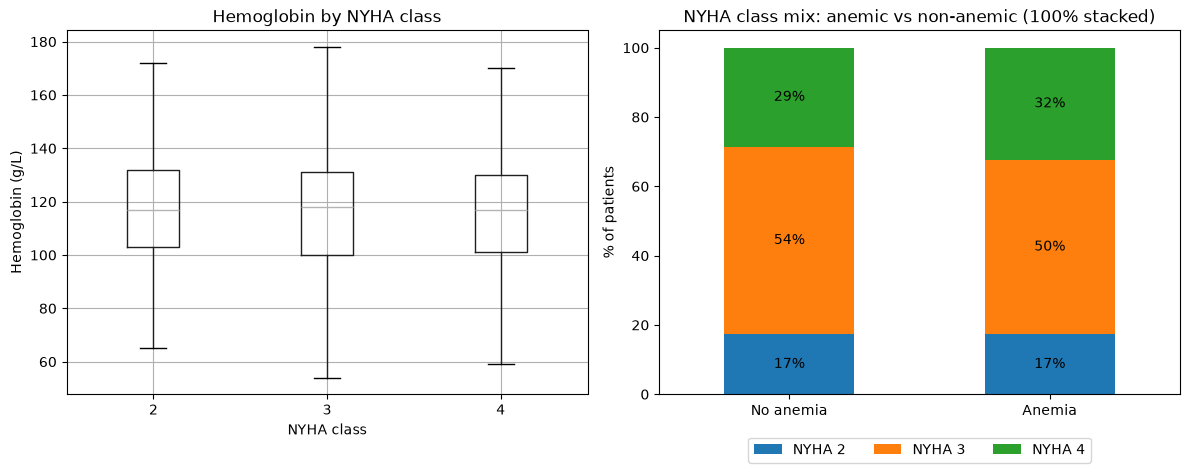

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
q4.boxplot(column="hemoglobin", by="nyha_cardiac_function_classification", ax=axes[0], showfliers=False)
axes[0].set_title("Hemoglobin by NYHA class")
axes[0].set_xlabel("NYHA class")
axes[0].set_ylabel("Hemoglobin (g/L)")
# 100% stacked bar: NYHA class mix for non-anemic vs anemic patients
mix = pd.crosstab(q4["anemia"], q4["nyha_cardiac_function_classification"], normalize="index") * 100
mix.index = ["No anemia", "Anemia"]
mix.columns = [f"NYHA {c}" for c in mix.columns]
mix.plot(kind="bar", stacked=True, ax=axes[1], rot=0)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f%%", label_type="center")
axes[1].set_title("NYHA class mix: anemic vs non-anemic (100% stacked)")
axes[1].set_ylabel("% of patients")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3)
plt.suptitle("")
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Anemia is common (61% of patients), but it is only weakly linked to outcomes here. Anemic patients are readmitted a little more often (40.7% vs 35.1%, OR 1.26, p = 0.018), but death is not significantly different (3.1% vs 2.5%), and hemoglobin is not linked to NYHA class (rho = -0.03). High RDW adds no clear extra risk. So in this data anemia is a modest readmission marker, not a strong sign of severity or death.<br><b>What this means:</b> anemia screening is still worth keeping in the discharge check because it is cheap and treatable (iron, cause work-up), and it slightly raises readmission. It should not be used as a main risk marker for death.</b></i></p>

<p style="font-family: Cambria; font-size: 16px; color:red;"><b>Q5. Which sodium and potassium ranges are associated with higher rates of mortality and readmission, and is electrolyte abnormality more common among patients receiving multiple diuretics?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>sodium, potassium, Furosemide injection / tablet, Torasemide tablet, Hydrochlorothiazide tablet, Spironolactone tablet, re_admission_within_6_months, death_within_28_days, death_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Sodium and potassium are salts that control the body's water balance and the heart's electrical rhythm. Low sodium happens when the body holds on to too much water, which is a sign of severe heart failure. Potassium that is too low or too high can cause dangerous heart rhythms. Diuretics (water tablets) remove fluid but also wash out sodium and potassium, while spironolactone can push potassium up. This group of markers should show which salt ranges carry the highest risk and whether patients on several diuretics more often have abnormal salts.</b></i></p>

In [11]:
q5 = df.dropna(subset=["sodium", "potassium"]).copy()

# Sodium and potassium ranges
q5["Sodium range"] = pd.cut(q5["sodium"], bins=[0, 130, 135, 137, 147.01, 999], right=False,
                            labels=["<130", "130-134", "135-136", "137-147 normal", ">147"])
q5["Potassium range"] = pd.cut(q5["potassium"], bins=[0, 3.5, 5.31, 99], right=False,
                               labels=["<3.5 low", "3.5-5.3 normal", ">5.3 high"])

cols = ["re_admission_within_6_months", "death_within_28_days", "death_within_6_months"]
sodium_table = (q5.groupby("Sodium range")[cols].mean() * 100).round(1)
sodium_table["patients"] = q5["Sodium range"].value_counts()
print(sodium_table)
potassium_table = (q5.groupby("Potassium range")[cols].mean() * 100).round(1)
potassium_table["patients"] = q5["Potassium range"].value_counts()
print(potassium_table)

# Number of diuretics each patient got, and % with a salt problem
diuretics = ["Furosemide injection", "Furosemide tablet", "Torasemide tablet", "Hydrochlorothiazide tablet", "Spironolactone tablet"]
q5["diuretic_count"] = q5[diuretics].sum(axis=1).clip(upper=4)
q5["salt_problem"] = ((q5["sodium"] < 135) | (q5["potassium"] < 3.5) | (q5["potassium"] > 5.3)).astype(int)
print((q5.groupby("diuretic_count")["salt_problem"].mean() * 100).round(1))

# Statistical tests
for col in cols:
    print("Sodium range vs", col, "p-value:", chi_square("Sodium range", col, q5))
    print("Potassium range vs", col, "p-value:", chi_square("Potassium range", col, q5))
print("Number of diuretics vs salt problem, p-value:", chi_square("diuretic_count", "salt_problem", q5))

                re_admission_within_6_months  death_within_28_days  \
Sodium range                                                         
<130                                    39.6                   4.7   
130-134                                 47.3                   2.8   
135-136                                 38.9                   2.8   
137-147 normal                          36.5                   1.1   
>147                                    35.7                   7.1   

                death_within_6_months  patients  
Sodium range                                     
<130                              6.6       106  
130-134                           4.3       281  
135-136                           3.6       247  
137-147 normal                    2.0      1349  
>147                              7.1        14  
                 re_admission_within_6_months  death_within_28_days  \
Potassium range                                                       
<3.5 low         

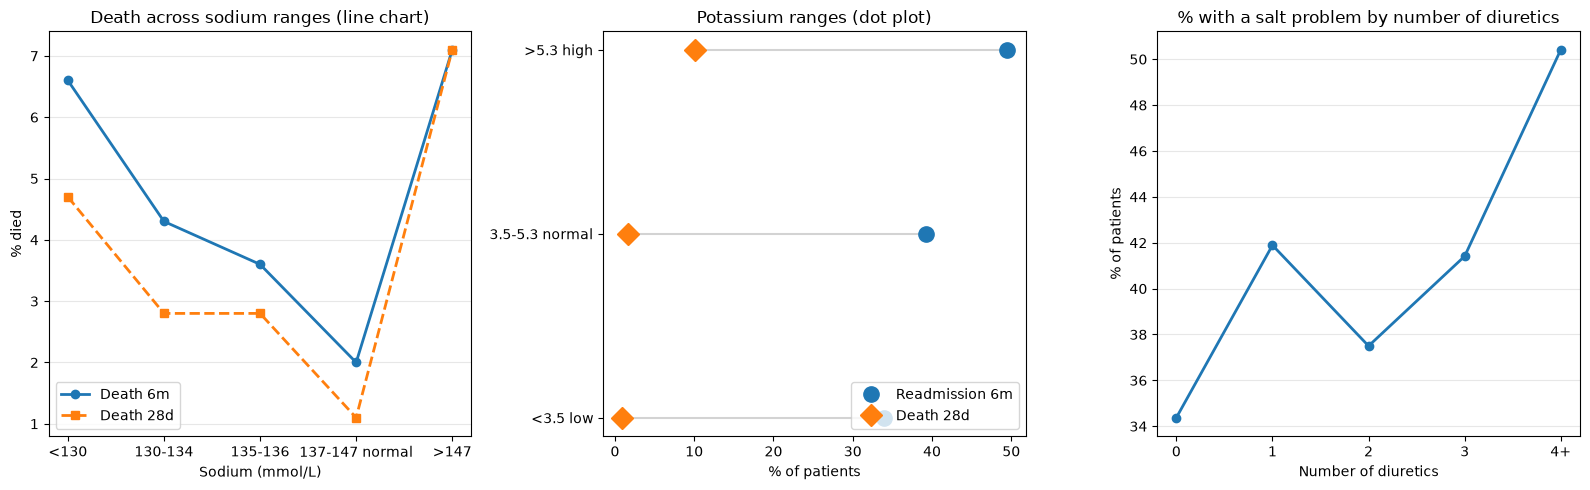

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# Line chart: death and readmission across sodium ranges
axes[0].plot(sodium_table.index.astype(str), sodium_table["death_within_6_months"], marker="o", linewidth=2, label="Death 6m")
axes[0].plot(sodium_table.index.astype(str), sodium_table["death_within_28_days"], marker="s", linestyle="--", linewidth=2, label="Death 28d")
axes[0].set_title("Death across sodium ranges (line chart)")
axes[0].set_xlabel("Sodium (mmol/L)")
axes[0].set_ylabel("% died")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
# Dot plot: potassium ranges
for col, name, marker in [("re_admission_within_6_months", "Readmission 6m", "o"), ("death_within_28_days", "Death 28d", "D")]:
    axes[1].plot(potassium_table[col], potassium_table.index.astype(str), marker, markersize=11, label=name)
for i, (r, d) in enumerate(zip(potassium_table["re_admission_within_6_months"], potassium_table["death_within_28_days"])):
    axes[1].hlines(i, d, r, colors="lightgray", zorder=0)
axes[1].set_title("Potassium ranges (dot plot)")
axes[1].set_xlabel("% of patients")
axes[1].legend(loc="lower right")
# Line chart: salt problems by number of diuretics
salt = q5.groupby("diuretic_count")["salt_problem"].mean() * 100
axes[2].plot(salt.index, salt.values, marker="o", linewidth=2)
axes[2].set_xticks([0, 1, 2, 3, 4], ["0", "1", "2", "3", "4+"])
axes[2].set_title("% with a salt problem by number of diuretics")
axes[2].set_xlabel("Number of diuretics")
axes[2].set_ylabel("% of patients")
axes[2].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Both salts matter. For sodium, risk rises as it falls: 6-month death is 2.0% in the normal range (137–147), 3.6% at 135–136, 4.3% at 130–134 and 6.6% below 130, and readmission peaks at 47% for 130–134. High potassium is the strongest single signal: above 5.3, 28-day death is 10.1% vs 1.6% in the normal range, and readmission is 49% vs 39%. Low potassium does not raise risk. Patients on 4 or more diuretics have salt problems more often (50% vs about 40%, p = 0.033), mainly low sodium (28%). The small group above 147 (only 14 patients) also shows high death on the line chart, but it is too small to rely on.<br><b>What this means:</b> sodium below 135 and potassium above 5.3 should both trigger a same-day review of fluids and medicines (diuretics, spironolactone, ACE inhibitors). Patients on 4 or more diuretics should have their salts rechecked before discharge.</b></i></p>

<p style="font-family: Cambria; font-size: 16px; color:red;"><b>Q6. Is an elevated D-dimer associated with higher mortality, and among patients receiving anticoagulant therapy, how frequently are INR values outside the expected range?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>d_dimer, international_normalized_ratio, warfarin sodium tablet, death_within_28_days, death_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>D-dimer is released when blood clots break down, so a high D-dimer means clots are forming somewhere in the body. Heart failure patients have slow blood flow and often an irregular heartbeat, which makes clots more likely, and clots in the lungs or brain can kill. INR measures how long the blood takes to clot; patients on warfarin should be kept between 2 and 3 to prevent clots without causing bleeding. A raised INR in patients not on warfarin can also mean the liver is congested and not making clotting proteins. This group of markers should show both clot risk and whether blood thinners are well controlled.</b></i></p>

In [13]:
q6 = df.dropna(subset=["d_dimer"]).copy()

# D-dimer in 4 equal groups
q6["D-dimer group"] = pd.qcut(q6["d_dimer"], 4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])
print(q6.groupby("D-dimer group")["d_dimer"].agg(["min", "max"]).round(2))
ddimer_table = (q6.groupby("D-dimer group")[["death_within_28_days", "death_within_6_months"]].mean() * 100).round(1)
print(ddimer_table)
print("D-dimer group vs 28-day death, p-value:", chi_square("D-dimer group", "death_within_28_days", q6))
print("D-dimer median (died, survived) and p-value:", mann_whitney("d_dimer", "death_within_28_days", q6))

# INR in warfarin patients: the target range is 2 to 3
warfarin = df[df["warfarin sodium tablet"] == 1].dropna(subset=["international_normalized_ratio"]).copy()
warfarin["INR range"] = pd.cut(warfarin["international_normalized_ratio"], bins=[0, 2, 3.0001, 99], right=False,
                               labels=["Below 2", "2-3 target", "Above 3"])
print("Warfarin patients:", len(warfarin))
print((warfarin["INR range"].value_counts(normalize=True) * 100).round(1))

# INR and death for all patients
inr = df.dropna(subset=["international_normalized_ratio"]).copy()
inr["INR range"] = pd.cut(inr["international_normalized_ratio"], bins=[0, 1.5, 2, 99], right=False, labels=["<=1.5 normal", "1.5-2", ">2"])
print((inr.groupby("INR range")["death_within_28_days"].mean() * 100).round(1))
print("INR range vs 28-day death, p-value:", chi_square("INR range", "death_within_28_days", inr))

                min     max
D-dimer group              
Q1 (lowest)    0.00    0.79
Q2             0.80    1.21
Q3             1.22    2.17
Q4 (highest)   2.18  100.10
               death_within_28_days  death_within_6_months
D-dimer group                                             
Q1 (lowest)                     0.4                    1.5
Q2                              1.1                    2.2
Q3                              1.7                    2.6
Q4 (highest)                    4.6                    5.3
D-dimer group vs 28-day death, p-value: <0.001
D-dimer median (died, survived) and p-value: (3.05, 1.2, '<0.001')
Warfarin patients: 253
INR range
Below 2       75.9
2-3 target    16.6
Above 3        7.5
Name: proportion, dtype: float64
INR range
<=1.5 normal    1.3
1.5-2           2.4
>2              8.3
Name: death_within_28_days, dtype: float64
INR range vs 28-day death, p-value: <0.001


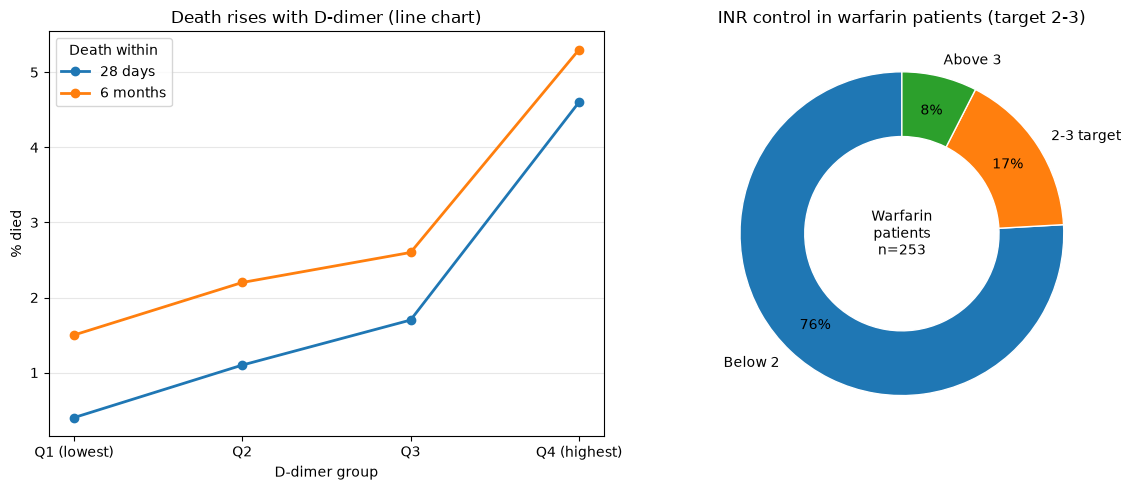

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Line chart: death across D-dimer quartiles
for col, name in [("death_within_28_days", "28 days"), ("death_within_6_months", "6 months")]:
    axes[0].plot(ddimer_table.index.astype(str), ddimer_table[col], marker="o", linewidth=2, label=name)
axes[0].set_title("Death rises with D-dimer (line chart)")
axes[0].set_xlabel("D-dimer group")
axes[0].set_ylabel("% died")
axes[0].legend(title="Death within")
axes[0].grid(axis="y", alpha=0.3)
# Donut chart: INR control in warfarin patients (parts of one group)
share = warfarin["INR range"].value_counts().sort_index()
axes[1].pie(share, labels=share.index, autopct="%1.0f%%", startangle=90, pctdistance=0.78,
            wedgeprops=dict(width=0.4, edgecolor="white"))
axes[1].text(0, 0, f"Warfarin\npatients\nn={len(warfarin)}", ha="center", va="center")
axes[1].set_title("INR control in warfarin patients (target 2-3)")
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>D-dimer is above the normal limit in 94% of patients, but higher levels still separate risk: 28-day death is 0.4% in the lowest quarter and 4.6% in the highest quarter (D-dimer above 2.17), and patients who died had a median D-dimer of 3.05 vs 1.20. For blood thinners, the result is striking: 76% of warfarin patients have an INR below the target of 2, only 17% are in the 2–3 target range and 8% are above 3. Across all patients, an INR above 2 goes with 8.3% 28-day death vs 1.3% with a normal INR.<br><b>What this means:</b> patients with D-dimer above about 2.2 should be checked for clots and closely monitored. Warfarin patients need their dose reviewed, because three out of four are not properly protected from clots, and any patient with INR above 2 who is not meant to be on warfarin should be checked for liver congestion or bleeding risk.</b></i></p>

<p style="font-family: Cambria; font-size: 16px; color:red;"><b>Q7. Are abnormal bilirubin, AST/ALT and albumin levels associated with higher tricuspid pressure and worse patient outcomes, suggesting a relationship between congestion and liver dysfunction?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>total_bilirubin (>20.4), ast_alt_ratio (>0.8), albumin (<35), tricuspid_valve_return_pressure, re_admission_within_6_months, death_within_28_days, death_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>When the right side of the heart fails, blood backs up into the veins and the liver becomes swollen and congested. A congested liver works less well: bilirubin rises, the AST/ALT ratio goes up, and less albumin is made. Tricuspid pressure estimates the pressure in the lung arteries, which drives this back-up. This group of markers should show whether higher lung pressure goes with worse liver tests, and whether patients with more abnormal liver markers have worse outcomes.</b></i></p>

In [15]:
q7 = df.copy()

# Correlation matrix: lung pressure and liver markers
liver_cols = ["tricuspid_valve_return_pressure", "total_bilirubin", "ast_alt_ratio", "albumin"]
print("Patients with tricuspid pressure:", q7["tricuspid_valve_return_pressure"].notna().sum())
print(q7[liver_cols].corr(method="spearman").round(2))

# Number of abnormal liver markers (a missing test counts as not abnormal)
q7["liver_abnormal"] = ((q7["total_bilirubin"] > 20.4).astype(int) + (q7["ast_alt_ratio"] > 0.8).astype(int)
                        + (q7["albumin"] < 35).astype(int))
cols = ["re_admission_within_6_months", "death_within_28_days", "death_within_6_months"]
liver_table = (q7.groupby("liver_abnormal")[cols].mean() * 100).round(1)
liver_table["patients"] = q7["liver_abnormal"].value_counts()
print(liver_table)

for col in cols:
    print("Abnormal liver markers vs", col, "p-value:", chi_square("liver_abnormal", col, q7))

Patients with tricuspid pressure: 178
                                 tricuspid_valve_return_pressure  \
tricuspid_valve_return_pressure                             1.00   
total_bilirubin                                            -0.02   
ast_alt_ratio                                               0.03   
albumin                                                    -0.04   

                                 total_bilirubin  ast_alt_ratio  albumin  
tricuspid_valve_return_pressure            -0.02           0.03    -0.04  
total_bilirubin                             1.00          -0.02     0.18  
ast_alt_ratio                              -0.02           1.00    -0.18  
albumin                                     0.18          -0.18     1.00  
                re_admission_within_6_months  death_within_28_days  \
liver_abnormal                                                       
0                                       37.2                   1.2   
1                                   

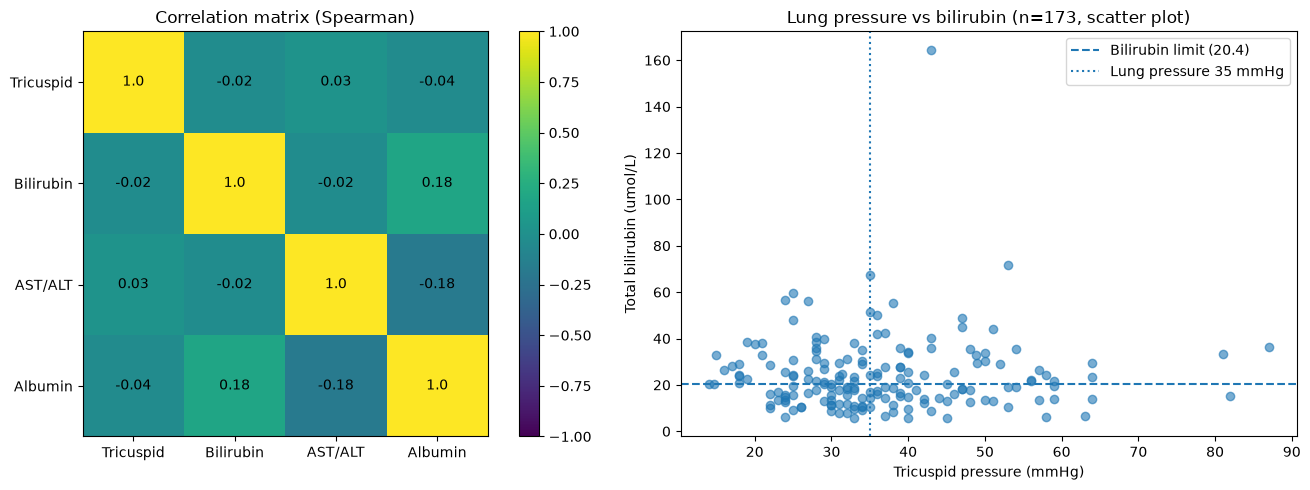

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
corr = q7[liver_cols].corr(method="spearman")
im = axes[0].imshow(corr, vmin=-1, vmax=1)
axes[0].set_xticks(range(4), ["Tricuspid", "Bilirubin", "AST/ALT", "Albumin"])
axes[0].set_yticks(range(4), ["Tricuspid", "Bilirubin", "AST/ALT", "Albumin"])
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, round(corr.iloc[i, j], 2), ha="center", va="center")
axes[0].set_title("Correlation matrix (Spearman)")
plt.colorbar(im, ax=axes[0])
# Scatter plot: lung pressure vs bilirubin (shows there is no link)
pair = q7[["tricuspid_valve_return_pressure", "total_bilirubin"]].dropna()
axes[1].scatter(pair["tricuspid_valve_return_pressure"], pair["total_bilirubin"], alpha=0.6)
axes[1].axhline(20.4, linestyle="--", label="Bilirubin limit (20.4)")
axes[1].axvline(35, linestyle=":", label="Lung pressure 35 mmHg")
axes[1].set_title(f"Lung pressure vs bilirubin (n={len(pair)}, scatter plot)")
axes[1].set_xlabel("Tricuspid pressure (mmHg)")
axes[1].set_ylabel("Total bilirubin (umol/L)")
axes[1].legend()
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The idea that high lung pressure goes with worse liver tests is not supported here: tricuspid pressure has almost no correlation with bilirubin, AST/ALT or albumin (all rho close to 0), but it is recorded for only 178 patients, so this part is weak. Liver markers do help with short-term risk: 28-day death is 1.2% with no abnormal liver marker, 2.9% with two and 6.4% with all three (p = 0.017), although the group with all three is small (47 patients). Readmission is not linked.<br><b>What this means:</b> patients with two or more abnormal liver markers (high bilirubin, high AST/ALT, low albumin) should get a closer review before discharge. Lung pressure should be measured more often by echo, because it is missing for over 90% of patients and the congestion link cannot be tested properly without it.</b></i></p>

<p style="font-family: Cambria; font-size: 16px; color:red;"><b>Q8. Among patients who received blood-gas testing, do elevated lactate, low pH and low oxygen saturation identify patients at higher risk of in-hospital death?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>lactate, ph, oxygen_saturation, outcome_during_hospitalization, death_within_28_days</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b><b>High lactate (>2.2):</b> May indicate poor tissue perfusion or greater illness severity.<br>
<b>Low pH (&lt;7.35):</b> Indicates acidemia and may reflect physiological stress.<br>
<b>Low oxygen saturation (&lt;93%):</b> Indicates reduced oxygen availability.<br>
<b>Fisher's exact test:</b> Tests whether the death rate differs between abnormal and non-abnormal groups. Because very few tested patients died in hospital, 28-day death is also tested as a second outcome.</b></i></p>


lactate (tested patients: 993, abnormal: 322)
In-hospital death: High = 1.86%, Not abnormal = 0.15% | Fisher p = 0.006
28-day death: High = 4.97%, Not abnormal = 1.64% | Fisher p = 0.005

ph (tested patients: 993, abnormal: 110)
In-hospital death: Low = 0.91%, Not abnormal = 0.68% | Fisher p = 0.562
28-day death: Low = 11.82%, Not abnormal = 1.59% | Fisher p = 0.000

oxygen_saturation (tested patients: 993, abnormal: 114)
In-hospital death: Low = 0.88%, Not abnormal = 0.68% | Fisher p = 0.575
28-day death: Low = 6.14%, Not abnormal = 2.28% | Fisher p = 0.027

In-hospital deaths among tested patients: 7


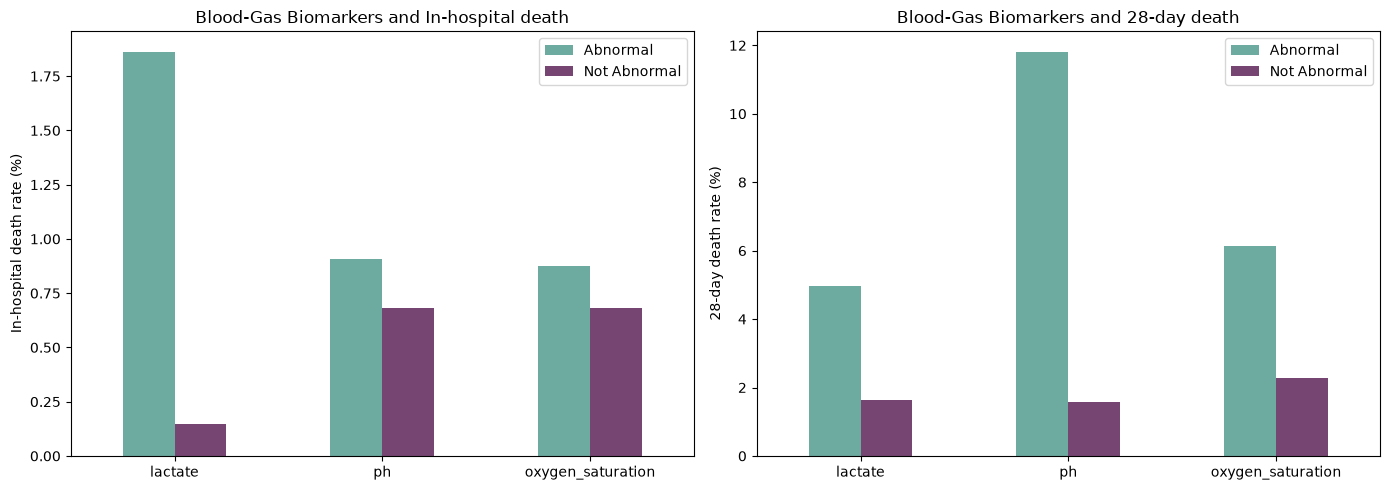

In [17]:
biomarkers = ["lactate", "ph", "oxygen_saturation"]

# In-hospital death and 28-day death
df["in_hospital_death"] = (df["outcome_during_hospitalization"] == "Dead").astype(int)
outcomes = {"in_hospital_death": "In-hospital death", "death_within_28_days": "28-day death"}

results = []

for col in biomarkers:

    # Keep patients who received blood-gas testing
    temp = df[[col, "in_hospital_death", "death_within_28_days"]].dropna(subset=[col])

    # Define abnormal values (normal ranges from the data dictionary)
    if col == "lactate":
        abnormal = temp[col] > 2.2
        label = "High"
    elif col == "ph":
        abnormal = temp[col] < 7.35
        label = "Low"
    else:
        abnormal = temp[col] < 93
        label = "Low"

    print(f"\n{col} (tested patients: {len(temp)}, abnormal: {abnormal.sum()})")

    for outcome, name in outcomes.items():
        death = temp[outcome] == 1

        # Death rates
        abnormal_rate = death[abnormal].mean() * 100
        normal_rate = death[~abnormal].mean() * 100

        # Fisher's exact test
        p_value = fisher_exact([
            [death[abnormal].sum(), (~death[abnormal]).sum()],
            [death[~abnormal].sum(), (~death[~abnormal]).sum()]
        ])[1]

        print(f"{name}: {label} = {abnormal_rate:.2f}%, Not abnormal = {normal_rate:.2f}% | Fisher p = {p_value:.3f}")
        results.append([col, name, abnormal_rate, normal_rate])

print("\nIn-hospital deaths among tested patients:", df.loc[df["lactate"].notna(), "in_hospital_death"].sum())


# Visualization
results = pd.DataFrame(results, columns=["Biomarker", "Outcome", "Abnormal", "Not Abnormal"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, name in zip(axes, outcomes.values()):
    results[results["Outcome"] == name].plot(
        x="Biomarker",
        y=["Abnormal", "Not Abnormal"],
        kind="bar",
        ax=ax,
        color=["#6daa9f", "#774571"]
    )
    ax.set_ylabel(f"{name} rate (%)")
    ax.set_title(f"Blood-Gas Biomarkers and {name}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="")

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>High lactate was the only blood-gas abnormality linked to in-hospital death (<b>1.86% vs 0.15%, p = 0.006</b>); low pH (0.91% vs 0.68%, p = 0.562) and low oxygen saturation (0.88% vs 0.68%, p = 0.575) were not significant. However, only <b>7</b> tested patients died in hospital, which is too few to test reliably. Using <b>28-day death</b>, all three markers were significant: low pH had the strongest link (<b>11.82% vs 1.59%, p &lt; 0.001</b>), followed by high lactate (<b>4.97% vs 1.64%, p = 0.005</b>) and low oxygen saturation (<b>6.14% vs 2.28%, p = 0.027</b>). Overall, abnormal blood-gas results, especially low pH and high lactate, identify patients at higher risk of early death.</b></i></p>

<p style="font-family: Cambria; font-size: 16px; color:red;"><b>Q9. Does worsening kidney function, reflected by lower eGFR and higher creatinine, urea or cystatin levels, correspond to higher rates of readmission and death?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>glomerular_filtration_rate (<60), creatinine_enzymatic_method (>110), urea (>8.3), cystatin (>0.98), re_admission_within_6_months, death_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Lower <b>eGFR</b> and higher <b>creatinine, urea and cystatin</b> can indicate reduced kidney function. Poor kidney function may be associated with greater fluid and waste accumulation and overall disease burden, which could increase the risk of readmission and death. Here, each biomarker is divided into <b>abnormal vs normal using the normal range from the data dictionary</b> (eGFR &lt; 60, creatinine &gt; 110, urea &gt; 8.3, cystatin &gt; 0.98), and 6-month readmission and death rates are compared using Fisher's exact test.</b></i></p>


eGFR < 60: 45.6% of patients abnormal
Readmission: Abnormal = 44.8%, Normal = 33.6% | p = 0.000
Death:       Abnormal = 4.0%, Normal = 2.0% | p = 0.014

Creatinine > 110: 31.9% of patients abnormal
Readmission: Abnormal = 46.2%, Normal = 35.2% | p = 0.000
Death:       Abnormal = 4.9%, Normal = 1.9% | p = 0.000

Urea > 8.3: 47.5% of patients abnormal
Readmission: Abnormal = 42.6%, Normal = 35.1% | p = 0.001
Death:       Abnormal = 4.0%, Normal = 1.7% | p = 0.003

Cystatin > 0.98: 91.0% of patients abnormal
Readmission: Abnormal = 39.3%, Normal = 34.5% | p = 0.226
Death:       Abnormal = 3.1%, Normal = 0.6% | p = 0.056


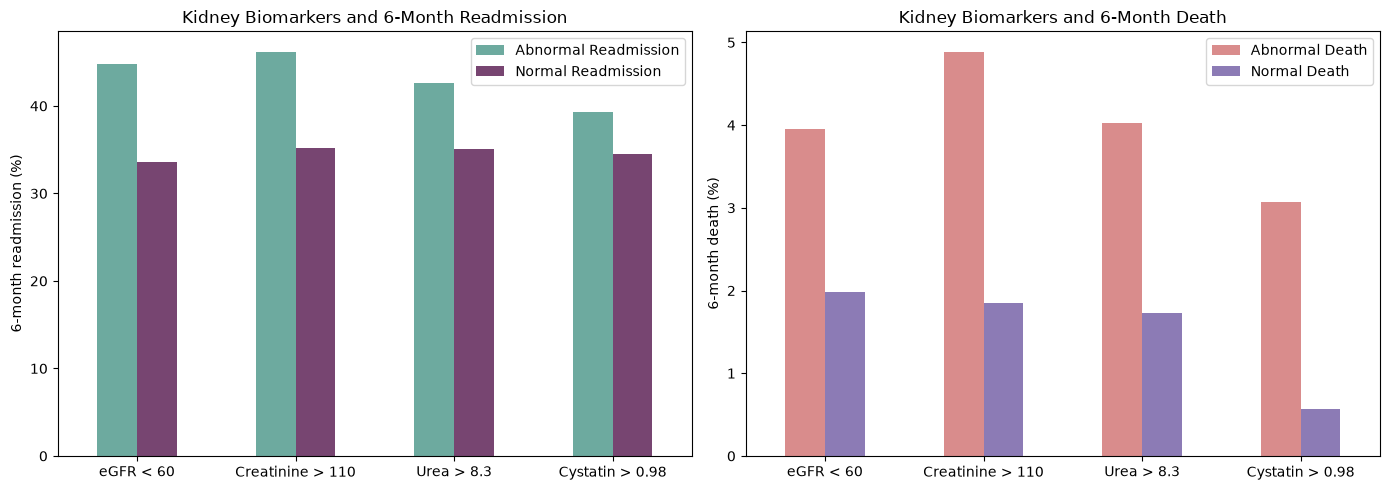

In [18]:
# Normal limits from the data dictionary: abnormal = outside the normal range
limits = {
    "glomerular_filtration_rate": ("eGFR < 60", lambda s: s < 60),
    "creatinine_enzymatic_method": ("Creatinine > 110", lambda s: s > 110),
    "urea": ("Urea > 8.3", lambda s: s > 8.3),
    "cystatin": ("Cystatin > 0.98", lambda s: s > 0.98),
}

results = []

for col, (name, rule) in limits.items():

    # Remove missing values
    temp = df[[col, "re_admission_within_6_months", "death_within_6_months"]].dropna(subset=[col])

    # Abnormal vs normal using the clinical limit
    high = rule(temp[col])

    # Outcomes
    readmission = temp["re_admission_within_6_months"] == 1
    death = temp["death_within_6_months"] == 1

    # Rates
    high_read = readmission[high].mean() * 100
    low_read = readmission[~high].mean() * 100

    high_death = death[high].mean() * 100
    low_death = death[~high].mean() * 100

    results.append([name, high_read, low_read, high_death, low_death])

    # Fisher tests
    p_read = fisher_exact([
        [readmission[high].sum(), (~readmission[high]).sum()],
        [readmission[~high].sum(), (~readmission[~high]).sum()]
    ])[1]

    p_death = fisher_exact([
        [death[high].sum(), (~death[high]).sum()],
        [death[~high].sum(), (~death[~high]).sum()]
    ])[1]

    print(f"\n{name}: {high.mean() * 100:.1f}% of patients abnormal")
    print(f"Readmission: Abnormal = {high_read:.1f}%, Normal = {low_read:.1f}% | p = {p_read:.3f}")
    print(f"Death:       Abnormal = {high_death:.1f}%, Normal = {low_death:.1f}% | p = {p_death:.3f}")


# Simple visualization
results = pd.DataFrame(
    results,
    columns=["Biomarker", "Abnormal Readmission", "Normal Readmission",
             "Abnormal Death", "Normal Death"]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
results.plot(x="Biomarker", y=["Abnormal Readmission", "Normal Readmission"], kind="bar",
             ax=axes[0], color=["#6daa9f", "#774571"])
axes[0].set_ylabel("6-month readmission (%)")
axes[0].set_title("Kidney Biomarkers and 6-Month Readmission")
results.plot(x="Biomarker", y=["Abnormal Death", "Normal Death"], kind="bar",
             ax=axes[1], color=["#d98c8c", "#8c7bb5"])
axes[1].set_ylabel("6-month death (%)")
axes[1].set_title("Kidney Biomarkers and 6-Month Death")
for ax in axes:
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="")
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Patients with abnormal kidney markers had higher 6-month readmission and death for three of the four markers. <b>eGFR below 60</b> (45.6% of patients): readmission <b>44.8% vs 33.6%</b> (p &lt; 0.001) and death <b>4.0% vs 2.0%</b> (p = 0.014). <b>Creatinine above 110</b> (31.9%): readmission <b>46.2% vs 35.2%</b> and death <b>4.9% vs 1.9%</b> (both p &lt; 0.001). <b>Urea above 8.3</b> (47.5%): readmission <b>42.6% vs 35.1%</b> (p = 0.001) and death <b>4.0% vs 1.7%</b> (p = 0.003). <b>Cystatin</b> was above the normal limit in 91% of patients, so it could not separate risk well (readmission p = 0.226, death p = 0.056). Overall, eGFR, creatinine and urea were significantly associated with higher 6-month readmission and mortality, with creatinine above 110 showing the largest difference.</b></i></p>

<p style="font-family: Cambria; font-size: 16px; color:red;"><b>Q10. Do patients with both abnormal kidney-function markers and abnormal cardiac markers experience worse outcomes than patients with only kidney abnormalities, only cardiac abnormalities, or neither?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>creatinine_enzymatic_method (>110), brain_natriuretic_peptide (>=708), death_within_6_months, re_admission_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Higher <b>creatinine</b> can indicate reduced kidney function, while higher <b>brain natriuretic peptide (BNP)</b> can indicate greater cardiac stress. Patients are divided into four groups based on whether creatinine is above its normal limit (<b>110 umol/L</b>) and whether BNP is <b>708 pg/mL or more</b> (the level where death risk rose in Q1; the normal limit of 100 is exceeded by 93% of patients, so it cannot separate groups). Six-month death and readmission rates are then compared across these four groups using chi-square tests.</b></i></p>

Outcome rates (%)


,Death,Readmission,Patients
Group,,,
Neither abnormal,1.0,35.0,689
Kidney only,2.1,40.3,236
Cardiac only,2.8,34.9,644
Both abnormal,6.7,49.5,390


Chi-square test for 6-month death: p = 0.0000
Chi-square test for 6-month readmission: p = 0.0000


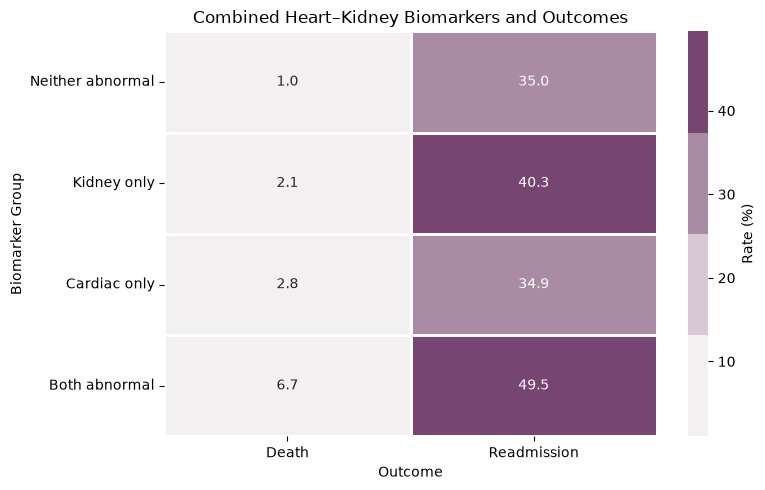

In [19]:
# Biomarkers
kidney = "creatinine_enzymatic_method"
cardiac = "brain_natriuretic_peptide"

# Keep patients with both biomarkers available
temp = df[[kidney, cardiac,
           "death_within_6_months",
           "re_admission_within_6_months"]].dropna(
    subset=[kidney, cardiac]
)

# Abnormal kidney = creatinine above the normal limit (110 umol/L, data dictionary)
# Abnormal cardiac = BNP 708 or more (the level where death risk rose in Q1; 93% of patients are above the normal limit of 100)
kidney_high = temp[kidney] > 110
cardiac_high = temp[cardiac] >= 708

# Create 4 groups
temp["Group"] = "Neither abnormal"
temp.loc[kidney_high & ~cardiac_high, "Group"] = "Kidney only"
temp.loc[~kidney_high & cardiac_high, "Group"] = "Cardiac only"
temp.loc[kidney_high & cardiac_high, "Group"] = "Both abnormal"

# Outcomes
temp["Death"] = temp["death_within_6_months"] == 1
temp["Readmission"] = temp["re_admission_within_6_months"] == 1

# Calculate outcome rates
results = temp.groupby("Group")[["Death", "Readmission"]].mean() * 100

# Put groups in logical order
order = [
    "Neither abnormal",
    "Kidney only",
    "Cardiac only",
    "Both abnormal"
]

results = results.reindex(order)
results["Patients"] = temp["Group"].value_counts().reindex(order)

print("Outcome rates (%)")
display(results.round(1))

# Statistical tests
for outcome in ["Death", "Readmission"]:
    table = pd.crosstab(temp["Group"], temp[outcome])
    chi2, p_value, dof, expected = chi2_contingency(table)
    print(f"Chi-square test for 6-month {outcome.lower()}: p = {p_value:.4f}")

# Heatmap
plt.figure(figsize=(8, 5))

sns.heatmap(
    results[["Death", "Readmission"]],
    annot=True,
    fmt=".1f",
    cmap=sns.color_palette(
        ["#f3f0f2", "#d8c8d5", "#a98ca3", "#774571"],
        as_cmap=True
    ),
    linewidths=1,
    cbar_kws={"label": "Rate (%)"}
)

plt.title("Combined Heart–Kidney Biomarkers and Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Biomarker Group")

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The <b>Both abnormal</b> group had the highest 6-month death rate (<b>6.7%</b>) and readmission rate (<b>49.5%</b>). The cardiac-only group had <b>2.8%</b> death and the kidney-only group <b>2.1%</b>, while the neither-abnormal group had the lowest death rate (<b>1.0%</b>). Readmission was similar in the neither-abnormal (<b>35.0%</b>) and cardiac-only (<b>34.9%</b>) groups, higher in the kidney-only group (<b>40.3%</b>) and highest when both were abnormal. Both mortality and readmission differed significantly across the four groups (<b>p &lt; 0.001</b>). Overall, patients with both abnormal kidney and cardiac biomarkers had the highest observed rates of death and readmission; abnormal kidney function mainly adds readmission risk, while high BNP mainly adds death risk.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q11. Is increasing NYHA functional class statistically associated with higher rates of readmission and death at 28 days, 3 months and 6 months?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>nyha_cardiac_function_classification, re_admission_within_28_days / 3_months / 6_months, death_within_28_days / 3_months / 6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Higher <b>NYHA functional class</b> represents greater limitation in physical activity and heart-failure symptoms. Patients are grouped by NYHA class (only Classes II–IV are present in this data), and readmission and death rates are calculated at 28 days, 3 months and 6 months. Chi-square tests assess whether outcomes differ across NYHA classes, while Spearman correlation evaluates whether outcome rates show a consistent trend as NYHA class increases.</b></i></p>


OUTCOME RATES BY NYHA FUNCTIONAL CLASS


,NYHA Class,Patients,Readmission 28 Days,Readmission 3 Months,Readmission 6 Months,Death 28 Days,Death 3 Months,Death 6 Months
0,2,353,4.0%,16.7%,29.2%,0.8%,1.4%,2.5%
1,3,1039,6.4%,24.3%,38.0%,0.7%,0.8%,1.7%
2,4,616,9.6%,30.4%,44.6%,4.4%,4.7%,4.9%



STATISTICAL ASSOCIATION / TREND TESTS


,Outcome,N,Chi-square p,Spearman rho,Spearman p
0,Readmission 28 Days,2008,0.0027,0.077,0.0006
1,Readmission 3 Months,2008,0.0000,0.105,0.0000
2,Readmission 6 Months,2008,0.0000,0.105,0.0000
3,Death 28 Days,2008,0.0000,0.108,0.0000
4,Death 3 Months,2008,0.0000,0.099,0.0000
5,Death 6 Months,2008,0.0009,0.063,0.0048


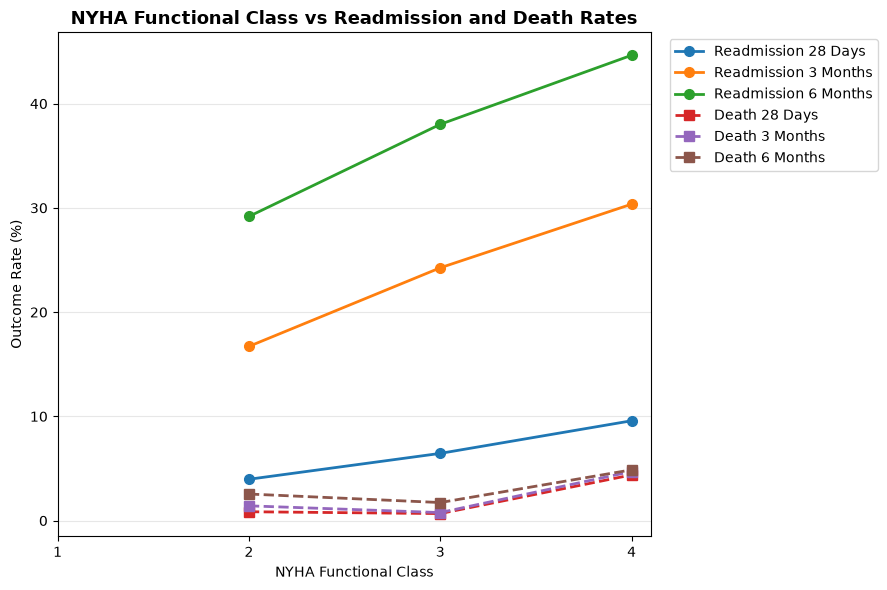


Statistically significant trends were observed for 6 of 6 outcomes.

Outcomes significantly associated with increasing NYHA class:
• Readmission 28 Days: rates generally increased with higher NYHA class (Spearman ρ = 0.08, p = 0.0006)
• Readmission 3 Months: rates generally increased with higher NYHA class (Spearman ρ = 0.11, p = 0.0000)
• Readmission 6 Months: rates generally increased with higher NYHA class (Spearman ρ = 0.11, p = 0.0000)
• Death 28 Days: rates generally increased with higher NYHA class (Spearman ρ = 0.11, p = 0.0000)
• Death 3 Months: rates generally increased with higher NYHA class (Spearman ρ = 0.10, p = 0.0000)
• Death 6 Months: rates generally increased with higher NYHA class (Spearman ρ = 0.06, p = 0.0048)

Interpretation: NYHA class is evaluated as an association/risk-stratification measure. Statistical association does not establish causation.


In [20]:
nyha_col = "nyha_cardiac_function_classification"

outcomes = {
    "re_admission_within_28_days": "Readmission 28 Days",
    "re_admission_within_3_months": "Readmission 3 Months",
    "re_admission_within_6_months": "Readmission 6 Months",
    "death_within_28_days": "Death 28 Days",
    "death_within_3_months": "Death 3 Months",
    "death_within_6_months": "Death 6 Months"
}

required_cols = [nyha_col] + list(outcomes.keys())

missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    print(" Missing columns:")
    print(missing_cols)

else:

    # --------------------------------------------------------
    # 2. Prepare Q11 dataset
    # --------------------------------------------------------

    q11 = df[required_cols].copy()

    # Convert NYHA to numeric
    q11[nyha_col] = pd.to_numeric(
        q11[nyha_col],
        errors="coerce"
    )

    # Convert outcomes to numeric
    for col in outcomes:
        q11[col] = pd.to_numeric(
            q11[col],
            errors="coerce"
        )

    # Keep valid NYHA classes I-IV
    q11 = q11[
        q11[nyha_col].isin([1, 2, 3, 4])
    ].copy()

    # --------------------------------------------------------
    # 3. Calculate outcome rates by NYHA class
    # --------------------------------------------------------

    rate_rows = []

    for nyha_class, group in q11.groupby(nyha_col):

        row = {
            "NYHA Class": int(nyha_class),
            "Patients": len(group)
        }

        for col, label in outcomes.items():

            valid = group[col].dropna()

            if len(valid) > 0:
                row[label] = valid.mean() * 100
            else:
                row[label] = np.nan

        rate_rows.append(row)

    rates = pd.DataFrame(rate_rows)

    # --------------------------------------------------------
    # 4. Statistical testing
    # --------------------------------------------------------

    statistical_results = []

    for col, label in outcomes.items():

        test_data = q11[
            [nyha_col, col]
        ].dropna()

        # Chi-square test
        contingency = pd.crosstab(
            test_data[nyha_col],
            test_data[col]
        )

        if (
            contingency.shape[0] >= 2
            and contingency.shape[1] >= 2
        ):
            chi2, chi_p, _, _ = chi2_contingency(
                contingency
            )
        else:
            chi2 = np.nan
            chi_p = np.nan

        # Spearman trend test
        if test_data[nyha_col].nunique() >= 2:

            rho, spear_p = spearmanr(
                test_data[nyha_col],
                test_data[col]
            )

        else:
            rho = np.nan
            spear_p = np.nan

        statistical_results.append({
            "Outcome": label,
            "N": len(test_data),
            "Chi-square p": chi_p,
            "Spearman rho": rho,
            "Spearman p": spear_p
        })

    stats_df = pd.DataFrame(
        statistical_results
    )

    # --------------------------------------------------------
    # 5. Display outcome rates
    # --------------------------------------------------------

    print("\n" + "=" * 80)
    print("OUTCOME RATES BY NYHA FUNCTIONAL CLASS")
    print("=" * 80)

    display(
        rates.style.format({
            col: "{:.1f}%"
            for col in rates.columns
            if col not in ["NYHA Class", "Patients"]
        })
    )

    # --------------------------------------------------------
    # 6. Display statistical results
    # --------------------------------------------------------

    print("\n" + "=" * 80)
    print("STATISTICAL ASSOCIATION / TREND TESTS")
    print("=" * 80)

    display(
        stats_df.style.format({
            "Chi-square p": "{:.4f}",
            "Spearman rho": "{:.3f}",
            "Spearman p": "{:.4f}"
        })
    )

    # --------------------------------------------------------
    # 7. Visualization
    # --------------------------------------------------------

    plt.figure(figsize=(9, 6))

    for col, label in outcomes.items():

        if "Readmission" in label:
            linestyle = "-"
            marker = "o"
        else:
            linestyle = "--"
            marker = "s"

        plt.plot(
            rates["NYHA Class"],
            rates[label],
            marker=marker,
            linestyle=linestyle,
            linewidth=2,
            markersize=7,
            label=label
        )

    plt.title(
        "NYHA Functional Class vs Readmission and Death Rates",
        fontsize=13,
        fontweight="bold"
    )

    plt.xlabel(
        "NYHA Functional Class",
        fontsize=10
    )

    plt.ylabel(
        "Outcome Rate (%)",
        fontsize=10
    )

    plt.xticks([1, 2, 3, 4])

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 8. Automatic insight
    # --------------------------------------------------------

    print("\n" + "=" * 80)
   
    print("=" * 80)

    significant = stats_df[
        stats_df["Spearman p"] < 0.05
    ]

    if len(significant) > 0:

        print(
            f"Statistically significant trends were observed "
            f"for {len(significant)} of {len(stats_df)} outcomes."
        )

        print(
            "\nOutcomes significantly associated with increasing NYHA class:"
        )

        for _, row in significant.iterrows():

            direction = (
                "increased"
                if row["Spearman rho"] > 0
                else "decreased"
            )

            print(
                f"• {row['Outcome']}: "
                f"rates generally {direction} with higher NYHA class "
                f"(Spearman ρ = {row['Spearman rho']:.2f}, "
                f"p = {row['Spearman p']:.4f})"
            )

    else:

        print(
            "No statistically significant monotonic association "
            "between increasing NYHA class and the examined outcomes "
            "was detected (Spearman p ≥ 0.05)."
        )

    print(
        "\nInterpretation: NYHA class is evaluated as an "
        "association/risk-stratification measure. "
        "Statistical association does not establish causation."
    )

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Readmission rates increased consistently with higher NYHA class, from <b>4.0% to 9.6%</b> at 28 days and from <b>29.2% to 44.6%</b> at 6 months. Death rates also increased, with 28-day mortality rising from <b>0.8% to 4.4%</b> and 6-month mortality from <b>2.5% to 4.9%</b>. 
All six outcomes showed statistically significant trends with increasing NYHA class (<b>Spearman p &lt; 0.05</b>). Overall, higher NYHA class was significantly associated with higher readmission and mortality rates across all measured time points.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q12. Is increasing Killip grade statistically associated with higher in-hospital and 28-day mortality, and at which grade does the observed mortality increase most substantially?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>killip_grade, outcome_during_hospitalization, death_within_28_days</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Higher <b>Killip grade</b> reflects increasing severity of heart failure and clinical congestion. In-hospital and 28-day mortality rates are compared across Killip Grades I–IV to determine whether mortality increases with worsening grade. Spearman correlation and chi-square tests are used to test the association between Killip grade and each mortality outcome, and the change in 28-day mortality between consecutive grades identifies where the largest observed increase occurs.</b></i></p>

,killip_grade,patients,in_hospital_mortality,mortality_28d,increase_28d
0,1,527,0.0,0.0,NaN
1,2,1029,0.3,0.8,0.8
2,3,392,0.8,3.8,3.0
3,4,60,8.3,23.3,19.5


In-hospital death: Spearman rho = 0.09, p = 0.0000 | chi-square p = 0.0000
28-day death: Spearman rho = 0.18, p = 0.0000 | chi-square p = 0.0000
Largest observed increase in 28-day mortality: Killip 3 → Killip 4 (19.5 percentage points)
Overall 28-day mortality: 1.8%


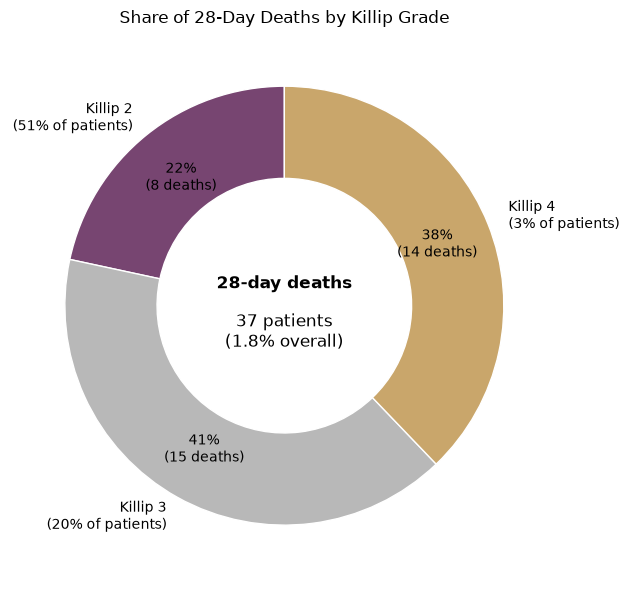

Killip 3-4: 23% of patients but 78% of 28-day deaths


In [21]:
killip = df[[
    "killip_grade",
    "outcome_during_hospitalization",
    "death_within_28_days"
]].copy()

killip["killip_grade"] = pd.to_numeric(killip["killip_grade"], errors="coerce")
killip["in_hospital_death"] = (killip["outcome_during_hospitalization"] == "Dead").astype(int)
killip["death_within_28_days"] = pd.to_numeric(
    killip["death_within_28_days"], errors="coerce"
)

killip = killip[killip["killip_grade"].isin([1, 2, 3, 4])]

summary = killip.groupby("killip_grade").agg(
    patients=("killip_grade", "size"),
    in_hospital_mortality=("in_hospital_death", "mean"),
    mortality_28d=("death_within_28_days", "mean")
).reset_index()

summary["in_hospital_mortality"] = summary["in_hospital_mortality"] * 100
summary["mortality_28d"] = summary["mortality_28d"] * 100
summary["increase_28d"] = summary["mortality_28d"].diff()

display(summary.round(1))

for outcome, name in [("in_hospital_death", "In-hospital death"), ("death_within_28_days", "28-day death")]:
    rho, p = spearmanr(killip["killip_grade"], killip[outcome])
    chi2, chi_p, dof, expected = chi2_contingency(pd.crosstab(killip["killip_grade"], killip[outcome]))
    print(f"{name}: Spearman rho = {rho:.2f}, p = {p:.4f} | chi-square p = {chi_p:.4f}")

largest = summary["increase_28d"].idxmax()

print(
    f"Largest observed increase in 28-day mortality: "
    f"Killip {int(summary.loc[largest, 'killip_grade'])-1} → "
    f"Killip {int(summary.loc[largest, 'killip_grade'])} "
    f"({summary.loc[largest, 'increase_28d']:.1f} percentage points)"
)

print(f"Overall 28-day mortality: {killip['death_within_28_days'].mean() * 100:.1f}%")

#=============================
# Visualization
#=============================

deaths = killip.groupby("killip_grade")["death_within_28_days"].sum()
deaths = deaths[deaths > 0]                      # Killip 1 had no deaths
patients_share = killip["killip_grade"].value_counts(normalize=True) * 100

cols = ["#6daa9f", "#774571", "#b8b8b8", "#c9a66b"]

plt.figure(figsize=(8, 6))

plt.pie(
    deaths,
    labels=[f"Killip {int(g)}\n({patients_share[g]:.0f}% of patients)" for g in deaths.index],
    colors=cols[1:len(deaths) + 1],
    startangle=90,
    autopct=lambda p: f"{p:.0f}%\n({round(p * deaths.sum() / 100)} deaths)",
    pctdistance=0.75,
    labeldistance=1.1,
    wedgeprops=dict(width=0.42, edgecolor="white")
)

# Centre text: real overall 28-day mortality
overall = killip["death_within_28_days"].mean() * 100
plt.text(0, 0.1, "28-day deaths", ha="center", va="center", fontsize=12, fontweight="bold")
plt.text(0, -0.12, f"{int(deaths.sum())} patients\n({overall:.1f}% overall)", ha="center", va="center", fontsize=12)

plt.title("Share of 28-Day Deaths by Killip Grade")
plt.tight_layout()
plt.show()

top = deaths.loc[[3, 4]].sum() / deaths.sum() * 100
print(f"Killip 3-4: {patients_share[[3, 4]].sum():.0f}% of patients but {top:.0f}% of 28-day deaths")

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>


<p style="font-family: Cambria; font-size: 16px;"><i><b>Mortality increased progressively with higher Killip grade. In-hospital mortality rose from <b>0.0%</b> in Killip 1 to <b>8.3%</b> in Killip 4, while 28-day mortality increased from <b>0.0%</b> to <b>23.3%</b>. Both associations were statistically significant (in-hospital: <b>Spearman rho = 0.09, p &lt; 0.001</b>; 28-day: <b>rho = 0.18, p &lt; 0.001</b>; chi-square <b>p &lt; 0.001</b> for both). The largest increase in 28-day mortality occurred from <b>Killip 3 to Killip 4</b>, rising by <b>19.5 percentage points</b>. Overall 28-day mortality was <b>1.8%</b>. These findings show a clear increase in observed mortality with worsening Killip grade, with the sharpest increase at Killip 4.</b></i></p>



<p style="font-family: Cambria; font-size: 16px; color:red;"><b>Q13. Are patients with an enlarged LVEDD and abnormal E/A filling pattern statistically more likely to experience readmission or death within 6 months than patients with normal cardiac structure or filling patterns?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>lvedd_enlarged_flag, ea_category, re_admission_within_6_months, death_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>An enlarged <b>LVEDD</b> (left ventricle wider than 56 mm) means the heart's main pumping chamber has stretched after long-term strain, and a stretched chamber pumps more weakly. The <b>E/A ratio</b> shows how the chamber fills with blood; a low or high E/A category suggests a stiff chamber or filling under high pressure. Patients are grouped by heart size (enlarged flag) and E/A category, and 6-month readmission and death rates are compared across the combined groups using chi-square tests.</b></i></p>

,lvedd_enlarged_flag,ea_category,patients,readmission,death
0,0.0,High,90,26.7,1.1
1,0.0,Intermediate,103,25.2,1.0
2,0.0,Low,153,24.8,2.6
3,1.0,High,73,32.9,0.0
4,1.0,Intermediate,54,27.8,5.6
5,1.0,Low,59,27.1,1.7


re_admission_within_6_months: p = 0.8725
death_within_6_months: p = 0.2552


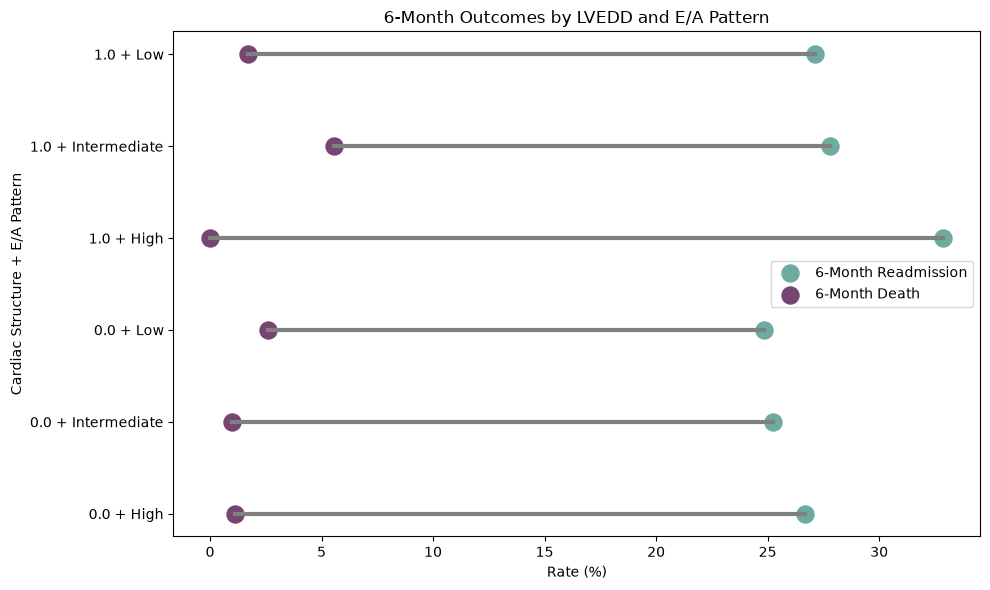

In [22]:
cols = ["#6daa9f", "#774571"]

summary = df.groupby(
    ["lvedd_enlarged_flag", "ea_category"]
).agg(
    patients=("inpatient_number", "count"),
    readmission=("re_admission_within_6_months", "mean"),
    death=("death_within_6_months", "mean")
).reset_index()

summary["readmission"] *= 100
summary["death"] *= 100

display(summary.round(1))

for outcome in ["re_admission_within_6_months", "death_within_6_months"]:
    table = pd.crosstab(
        [df["lvedd_enlarged_flag"], df["ea_category"]],
        df[outcome]
    )
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"{outcome}: p = {p:.4f}")

plt.figure(figsize=(10, 6))

for i, row in summary.iterrows():
    plt.plot(
        [row["readmission"], row["death"]],
        [i, i],
        color="gray",
        linewidth=3
    )

plt.scatter(
    summary["readmission"],
    range(len(summary)),
    s=150,
    color=cols[0],
    label="6-Month Readmission"
)

plt.scatter(
    summary["death"],
    range(len(summary)),
    s=150,
    color=cols[1],
    label="6-Month Death"
)

plt.yticks(
    range(len(summary)),
    summary["lvedd_enlarged_flag"].astype(str)
    + " + "
    + summary["ea_category"].astype(str)
)

plt.xlabel("Rate (%)")
plt.ylabel("Cardiac Structure + E/A Pattern")
plt.title("6-Month Outcomes by LVEDD and E/A Pattern")
plt.legend()

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The highest 6-month readmission rate was observed in the <b>enlarged LVEDD + High E/A</b> group (<b>32.9%</b>), while the highest death rate was observed in the <b>enlarged LVEDD + Intermediate E/A</b> group (<b>5.6%</b>). However, the differences across the combined groups were not statistically significant for either readmission (<b>p = 0.8725</b>) or death (<b>p = 0.2552</b>). Overall, the combined LVEDD and E/A patterns did not show a statistically significant association with 6-month outcomes in this dataset.</b></i></p>

<p style="font-family: Cambria; font-size: 16px; color:red;"><b>Q14. Do left-sided, right-sided and combined heart failure differ significantly in tricuspid pressure, BNP levels and patient outcomes?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>type_of_heart_failure, tricuspid_valve_return_pressure, bnp_log, re_admission_within_6_months, death_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b><b>Heart failure type</b> shows which side of the heart is failing: left-sided failure backs fluid up into the lungs, right-sided failure backs fluid up into the body, and both-sided failure does both. <b>Tricuspid pressure</b> estimates the pressure in the lung arteries and <b>BNP</b> (log value) shows how stretched the heart is. Mean tricuspid pressure, BNP and 6-month readmission and death rates are compared across the three types, and chi-square tests check whether readmission and death differ between types.</b></i></p>

,type_of_heart_failure,patients,tricuspid_pressure,BNP,readmission_6m,death_6m
0,Both,1480,36.56,6.56,42.23,3.11
1,Left,477,34.67,6.48,27.25,2.31
2,Right,51,49.00,6.43,35.29,0.00


Readmission chi-square p = 0.0000
Death chi-square p = 0.3057


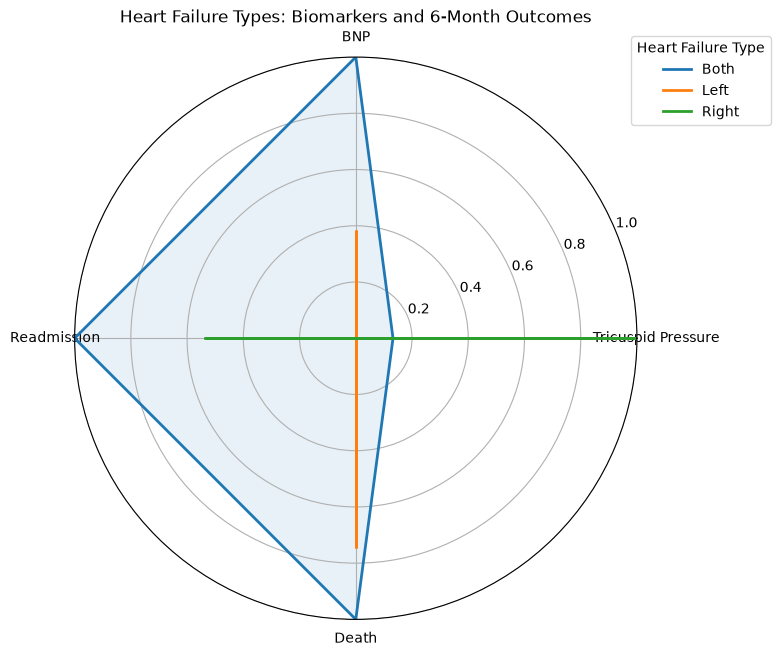

In [23]:
summary = df.groupby("type_of_heart_failure").agg(
    patients=("inpatient_number", "count"),
    tricuspid_pressure=("tricuspid_valve_return_pressure", "mean"),
    BNP=("bnp_log", "mean"),
    readmission_6m=("re_admission_within_6_months", "mean"),
    death_6m=("death_within_6_months", "mean")
).reset_index()

# Convert outcome rates to percentages
summary["readmission_6m"] *= 100
summary["death_6m"] *= 100

# Show results
display(summary.round(2))


# ---------------------------------------------------------
# Statistical tests
# ---------------------------------------------------------

# Readmission
read_table = pd.crosstab(df["type_of_heart_failure"], df["re_admission_within_6_months"])

chi2, p_read, dof, expected = chi2_contingency(read_table)

# Death
death_table = pd.crosstab( df["type_of_heart_failure"],df["death_within_6_months"])

chi2, p_death, dof, expected = chi2_contingency(death_table)

print(f"Readmission chi-square p = {p_read:.4f}")
print(f"Death chi-square p = {p_death:.4f}")


# ---------------------------------------------------------
# Radar Chart
# ---------------------------------------------------------

radar = summary.copy()

measures = [
    "tricuspid_pressure",
    "BNP",
    "readmission_6m",
    "death_6m"
]

# Normalize each measure from 0 to 1
for col in measures:

    minimum = radar[col].min()
    maximum = radar[col].max()

    if maximum != minimum:
        radar[col] = (
            (radar[col] - minimum)
            / (maximum - minimum)
        )
    else:
        radar[col] = 0


# Radar labels
labels = [
    "Tricuspid Pressure",
    "BNP",
    "Readmission",
    "Death"
]

angles = np.linspace(
    0,
    2 * np.pi,
    len(labels),
    endpoint=False
).tolist()

angles += angles[:1]


# Create radar chart
fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

for _, row in radar.iterrows():

    values = row[measures].tolist()
    values += values[:1]

    ax.plot( angles,values,linewidth=2,label=str(row["type_of_heart_failure"]) )

    ax.fill(angles,values, alpha=0.10)


ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

ax.set_ylim(0, 1)

ax.set_title( "Heart Failure Types: Biomarkers and 6-Month Outcomes",pad=25)

ax.legend( title="Heart Failure Type", bbox_to_anchor=(1.25, 1.05))

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The <b>Both</b> heart-failure group had the highest 6-month readmission rate (<b>42.23%</b>), followed by the <b>Right</b> group (<b>35.29%</b>) and <b>Left</b> group (<b>27.25%</b>). Readmission differed significantly across heart-failure types (<b>p &lt; 0.001</b>). The Right group had the highest mean tricuspid pressure (<b>49.00</b>), but tricuspid pressure was recorded for only 2 right-sided and 6 left-sided patients, so this difference cannot be relied on. Mean log BNP was similar across the three groups (6.43–6.56). Although 6-month death was highest in the Both group (<b>3.11%</b>), the difference in mortality was <b>not statistically significant</b> (<b>p = 0.3057</b>). Overall, heart-failure type was significantly associated with readmission, but not with 6-month mortality in this dataset.</b></i></p>

<p style="font-family: Cambria; font-size: 16px; color:red;"><b>Q15. Does increasing Charlson Comorbidity Index (CCI) score correspond to progressively higher rates of readmission and death?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>cci_score, re_admission_within_6_months, death_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>A higher <b>Charlson Comorbidity Index (CCI)</b> represents a greater burden of coexisting conditions. Patients are grouped by CCI score, and 6-month readmission and death rates are compared across the scores. Chi-square tests assess differences between CCI groups, while Spearman correlation evaluates whether the outcomes show a consistent trend as CCI increases.</b></i></p>

,cci_score,patients,readmission_6m,death_6m
0,0.0,56,44.6,10.7
1,1.0,770,34.9,1.9
2,2.0,699,37.3,2.7
3,3.0,368,42.1,2.7
4,4.0,94,54.3,6.4
5,5.0,15,60.0,6.7
6,6.0,1,100.0,0.0


Readmission chi-square p = 0.0013
Readmission Spearman rho = 0.071, p = 0.0015
Death chi-square p = 0.0029
Death Spearman rho = 0.015, p = 0.4984


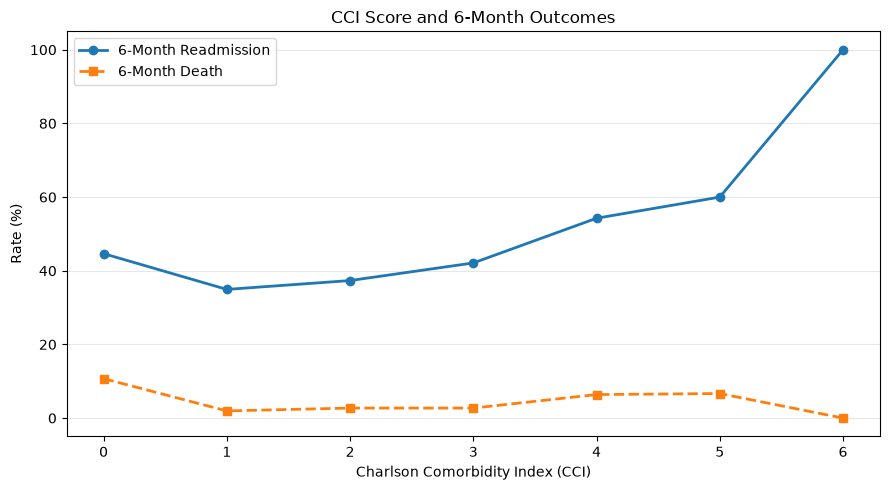

In [24]:
summary = df.groupby("cci_score").agg(
    patients=("inpatient_number", "count"),
    readmission_6m=("re_admission_within_6_months", "mean"),
    death_6m=("death_within_6_months", "mean")
).reset_index()

summary["readmission_6m"] *= 100
summary["death_6m"] *= 100

display(summary.round(1))

# Chi-square tests
read_table = pd.crosstab(
    df["cci_score"],
    df["re_admission_within_6_months"]
)

chi2, p_read, dof, expected = chi2_contingency(read_table)

death_table = pd.crosstab( df["cci_score"],df["death_within_6_months"])

chi2, p_death, dof, expected = chi2_contingency(death_table)

# Spearman trend tests
read_data = df[
    ["cci_score", "re_admission_within_6_months"]
].dropna()

death_data = df[
    ["cci_score", "death_within_6_months"]
].dropna()

rho_read, spear_read = spearmanr(
    read_data["cci_score"],
    read_data["re_admission_within_6_months"]
)

rho_death, spear_death = spearmanr(
    death_data["cci_score"],
    death_data["death_within_6_months"]
)

print(f"Readmission chi-square p = {p_read:.4f}")
print(f"Readmission Spearman rho = {rho_read:.3f}, p = {spear_read:.4f}")

print(f"Death chi-square p = {p_death:.4f}")
print(f"Death Spearman rho = {rho_death:.3f}, p = {spear_death:.4f}")


# Line chart
plt.figure(figsize=(9, 5))

plt.plot(
    summary["cci_score"],
    summary["readmission_6m"],
    marker="o",
    linewidth=2,
    label="6-Month Readmission"
)

plt.plot(
    summary["cci_score"],
    summary["death_6m"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="6-Month Death"
)

plt.xlabel("Charlson Comorbidity Index (CCI)")
plt.ylabel("Rate (%)")
plt.title("CCI Score and 6-Month Outcomes")

plt.xticks(summary["cci_score"])
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Six-month readmission rates generally increased with higher CCI scores, ranging from <b>34.9%</b> at CCI 1 to <b>60.0%</b> at CCI 5. The two ends of the line chart are based on very few patients: CCI 6 is a single patient (shown as 100%) and CCI 0 has 56 patients. The association with readmission was statistically significant by both chi-square (<b>p = 0.0013</b>) and Spearman correlation (<b>rho = 0.071, p = 0.0015</b>). Death rates also differed across CCI groups by chi-square (<b>p = 0.0029</b>), mainly because of the small CCI 0 group (10.7% death), but the Spearman trend was not statistically significant (<b>rho = 0.015, p = 0.4984</b>). Overall, higher CCI was significantly associated with 6-month readmission, while a consistent increasing trend in mortality was not demonstrated.</b></i></p>